In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_resnet1d, plot_loss_vs_epoch, evaluate_resnet_vitaldb, train_resnet1d_se, train_resnet1d_cbam, train_resnet1d_dilated

In [3]:
WINDOW_SIZE = 1000
STEP_SIZE = 500

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_50%overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:10<00:00, 73.60it/s] 


Skipped recordings: 103


100%|██████████| 1200/1200 [00:17<00:00, 67.49it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:18<00:00, 63.87it/s]


Skipped recordings: 9


Device: cuda
X_train: torch.Size([517037, 1, 1000])
y_train: torch.Size([517037, 2])
X_val: torch.Size([65284, 1, 1000])
y_val: torch.Size([65284, 2])
X_test: torch.Size([65554, 1, 1000])
y_test: torch.Size([65554, 2])
Epoch 01/100 | Train Loss: 5127.8586 | Val Loss: 828.6118 | Train SBP RMSE: 93.223 | Train DBP RMSE: 39.561 | Val SBP RMSE: 39.589 | Val DBP RMSE: 9.485 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 306.9409 | Val Loss: 190.7947 | Train SBP RMSE: 22.629 | Train DBP RMSE: 10.091 | Val SBP RMSE: 17.327 | Val DBP RMSE: 9.020 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 182.4407 | Val Loss: 241.8803 | Train SBP RMSE: 16.674 | Train DBP RMSE: 9.320 | Val SBP RMSE: 19.958 | Val DBP RMSE: 9.243 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 160.6130 | Val Loss: 166.2236 | Train SBP RMSE: 15.586 | Train DBP RMSE: 8.849 | Val SBP RMSE: 16.062 | Val DBP RMSE: 8.629 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 145.0991 | Val Loss: 163.5264 | Train SBP RMSE: 14.778 | Train DBP RMSE: 8.474 | Val SB

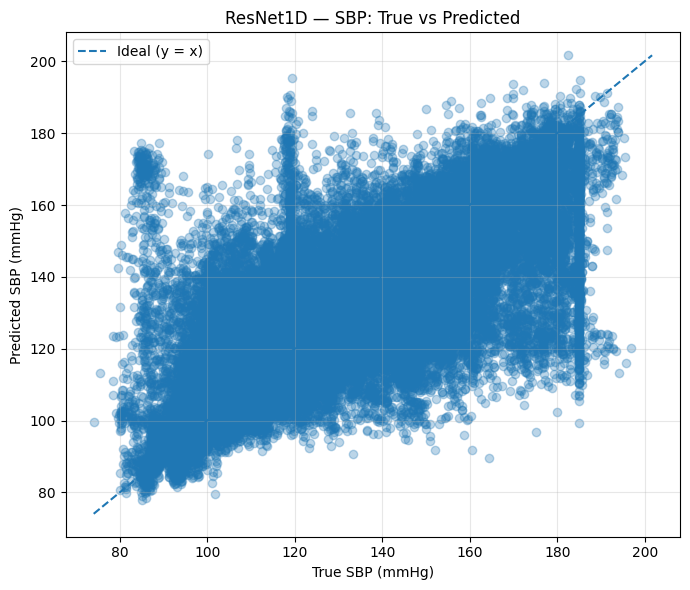

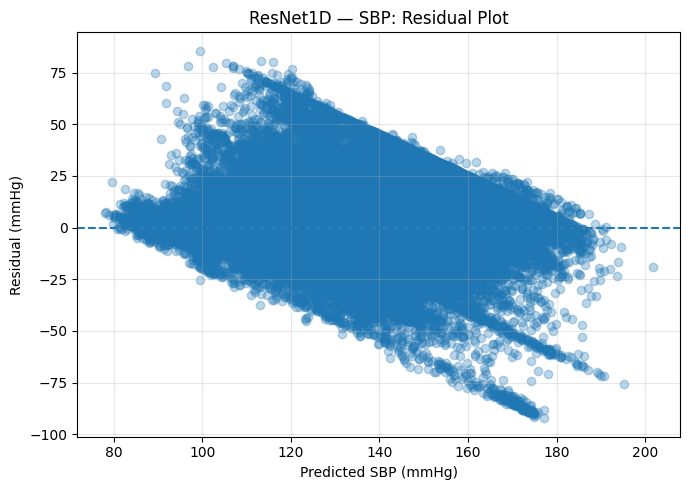

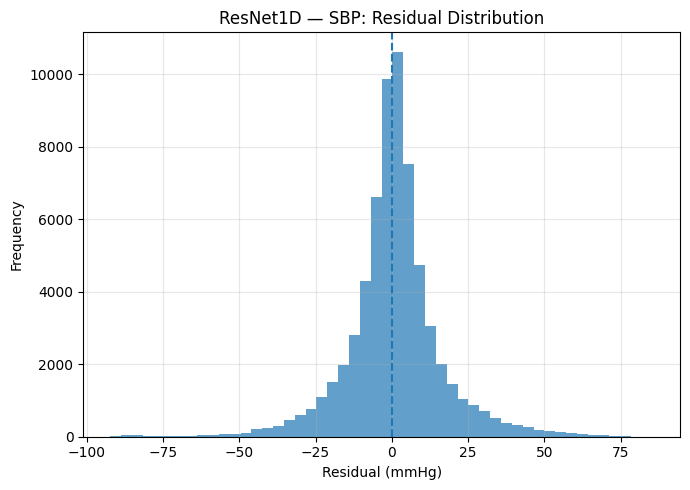

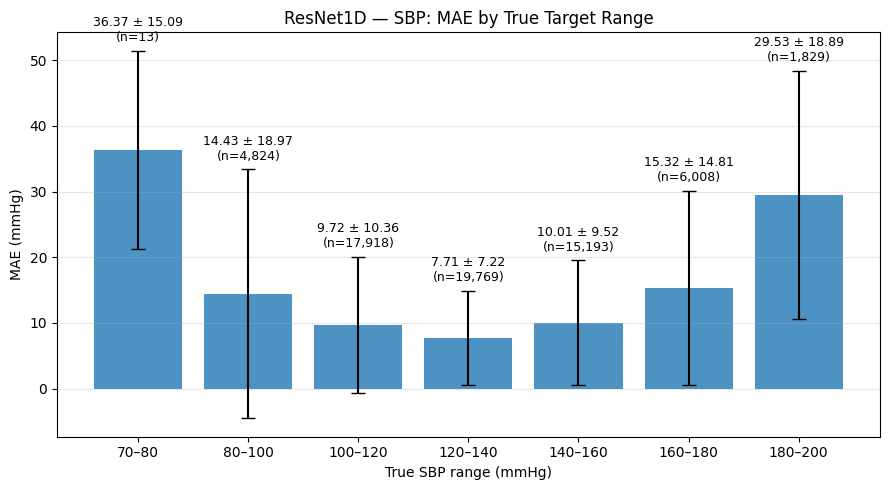

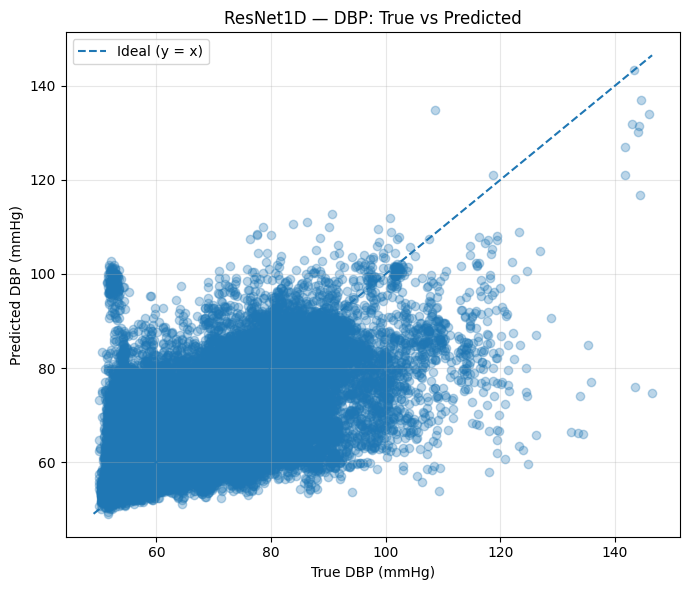

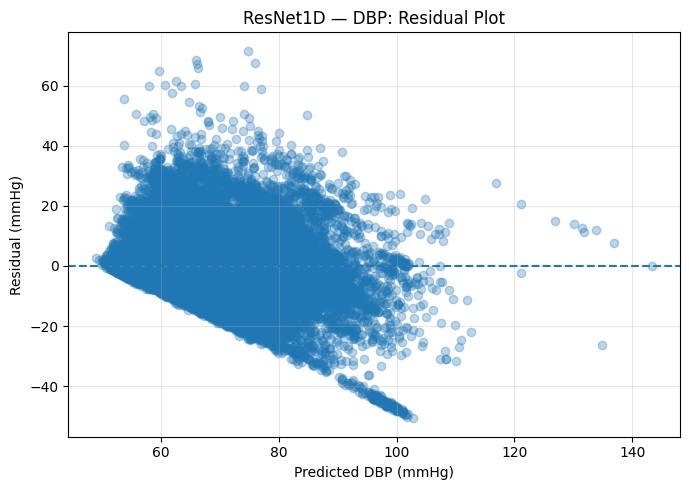

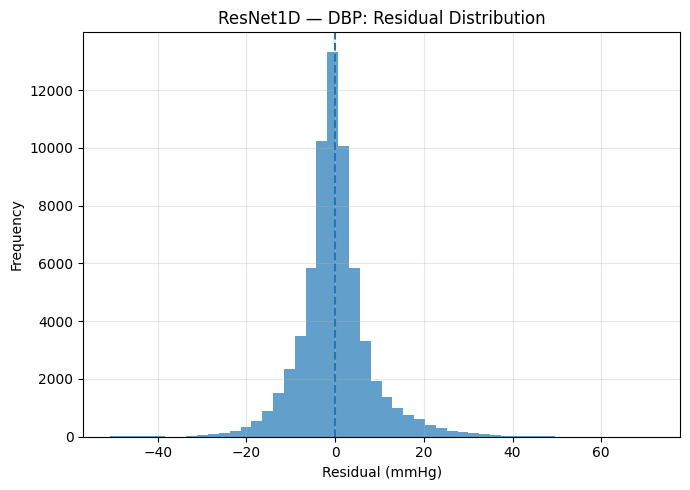

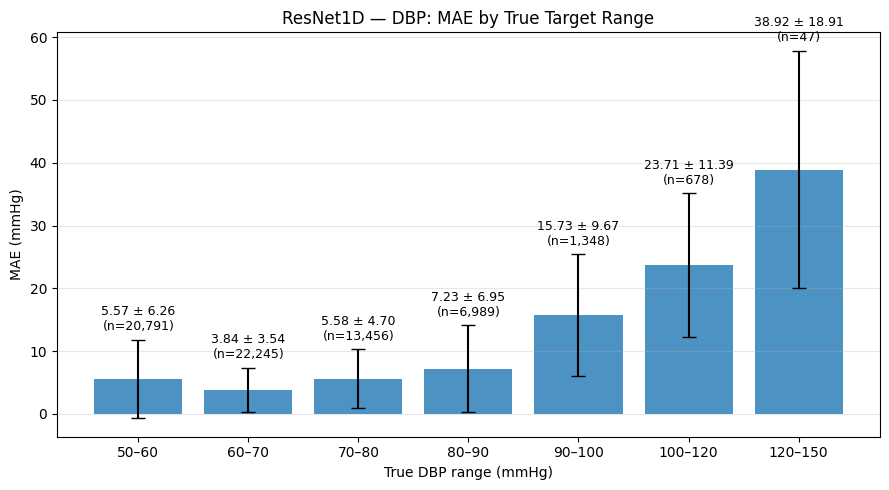

In [4]:
resnet_model, resnet_results = train_resnet1d(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

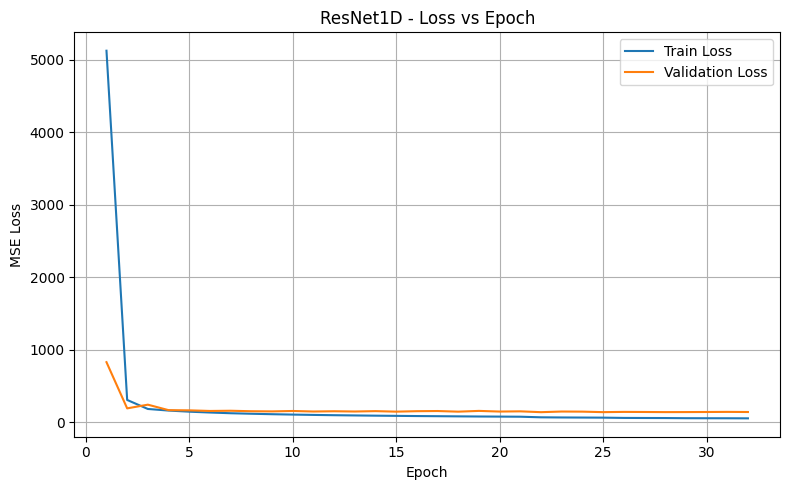

In [5]:
plot_loss_vs_epoch(
    resnet_results["history"],
    model_name="ResNet1D"
)

Number of VitalDB cases: 1962


ResNet1D VitalDB prediction: 100%|██████████| 1962/1962 [07:12<00:00,  4.54case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 27.5927
MSE : 761.3590
R²  : -0.7849
MAE : 21.8238

DBP
RMSE: 14.9153
MSE : 222.4669
R²  : -0.3753
MAE : 11.7762


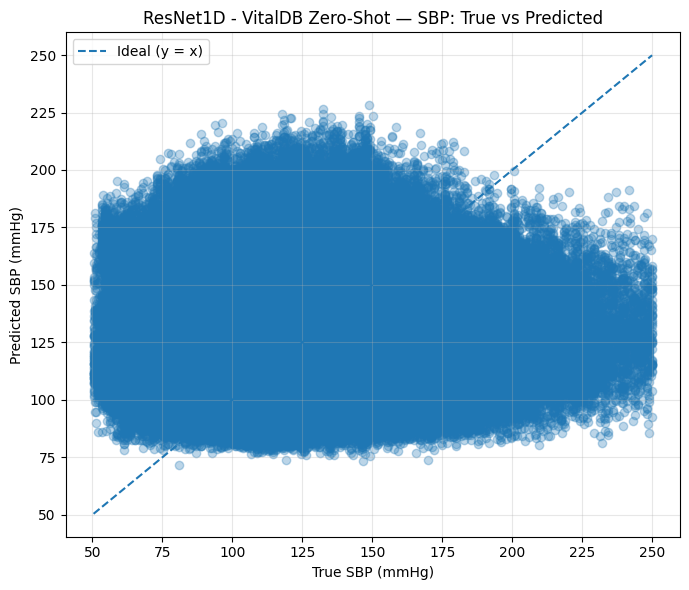

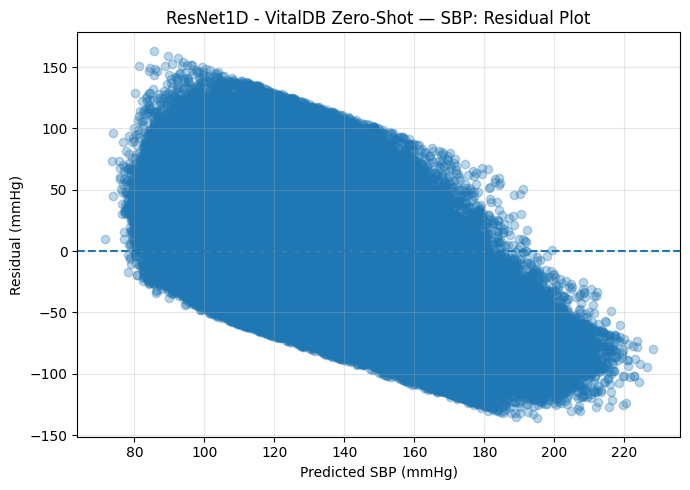

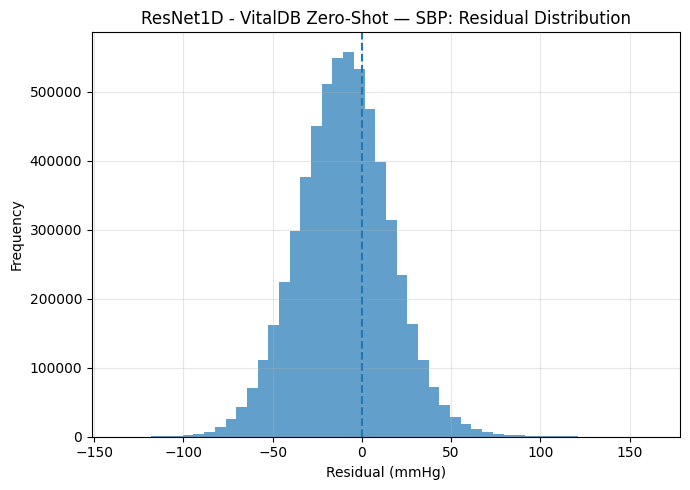

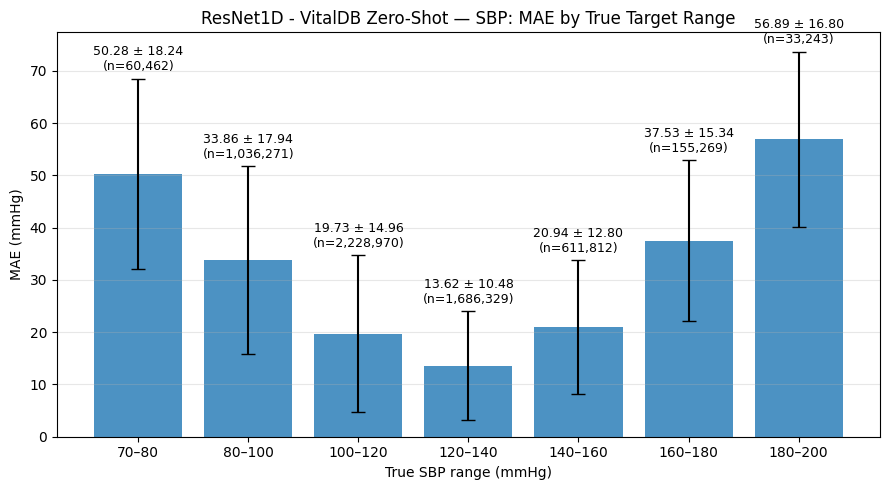

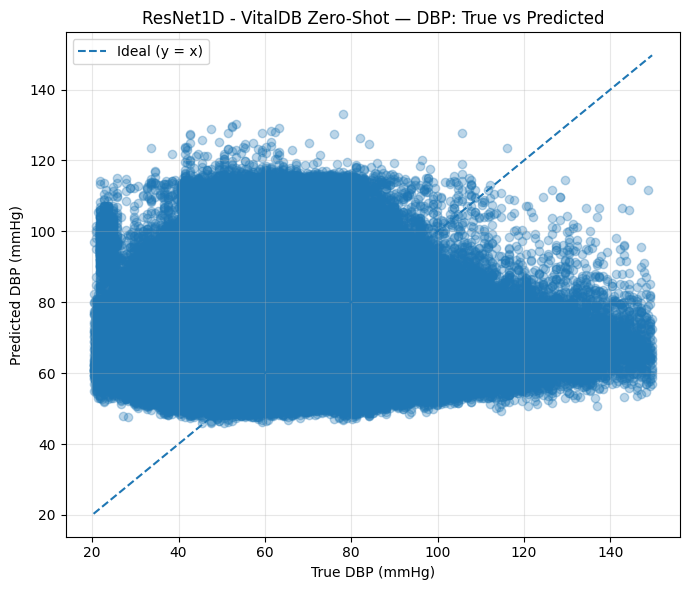

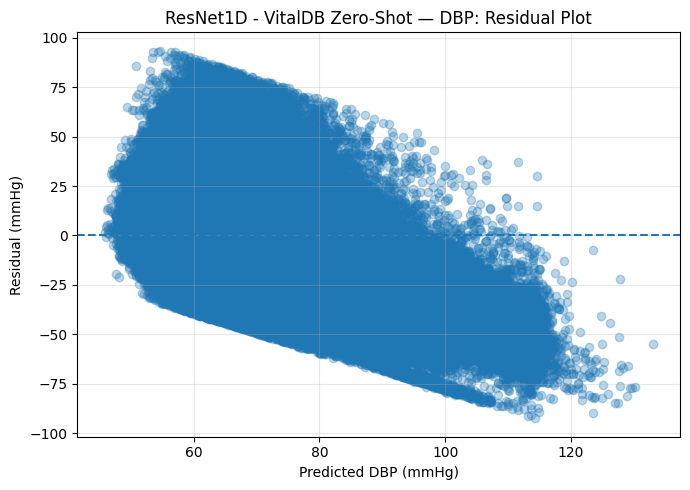

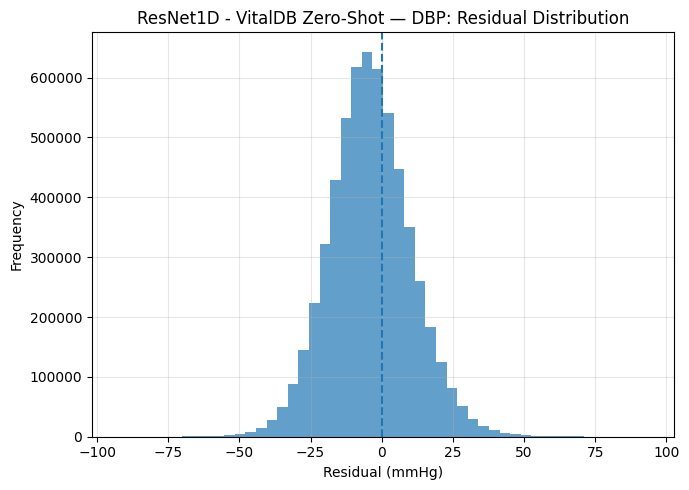

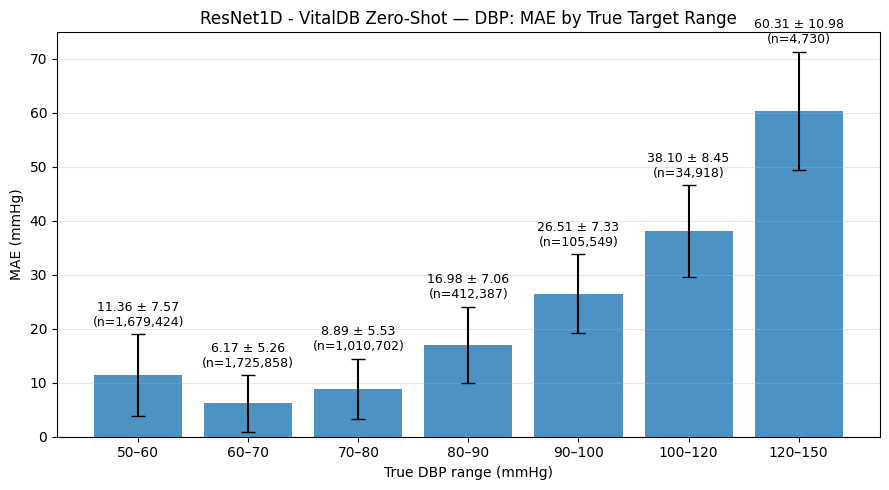

In [6]:
resnet_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## SE Activation ##

Device: cuda
X_train: torch.Size([517037, 1, 1000])
y_train: torch.Size([517037, 2])
X_val: torch.Size([65284, 1, 1000])
y_val: torch.Size([65284, 2])
X_test: torch.Size([65554, 1, 1000])
y_test: torch.Size([65554, 2])
Epoch 01/100 | Train Loss: 5585.2111 | Val Loss: 1163.4581 | Train SBP RMSE: 97.451 | Train DBP RMSE: 40.912 | Val SBP RMSE: 47.205 | Val DBP RMSE: 9.930 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 532.6019 | Val Loss: 207.8388 | Train SBP RMSE: 30.795 | Train DBP RMSE: 10.811 | Val SBP RMSE: 18.019 | Val DBP RMSE: 9.539 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 225.0019 | Val Loss: 194.8161 | Train SBP RMSE: 18.636 | Train DBP RMSE: 10.135 | Val SBP RMSE: 17.378 | Val DBP RMSE: 9.361 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 197.0301 | Val Loss: 199.2996 | Train SBP RMSE: 17.418 | Train DBP RMSE: 9.521 | Val SBP RMSE: 17.737 | Val DBP RMSE: 9.165 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 175.5609 | Val Loss: 179.6717 | Train SBP RMSE: 16.406 | Train DBP RMSE: 9.053 | Val 

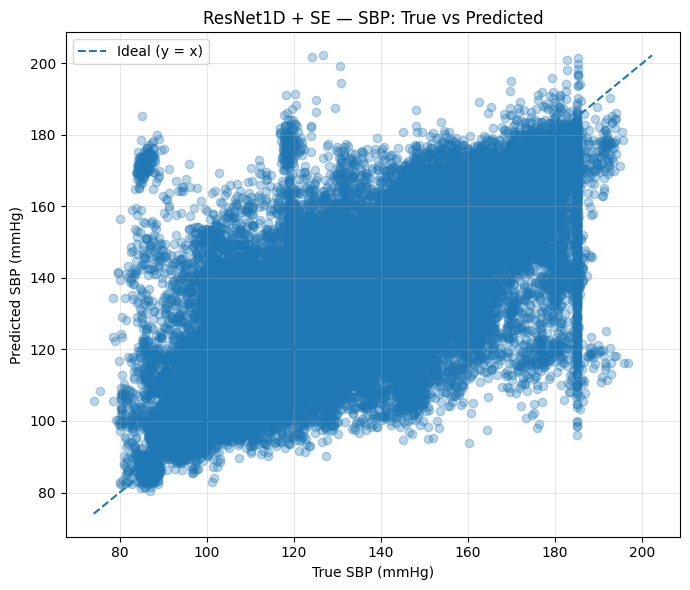

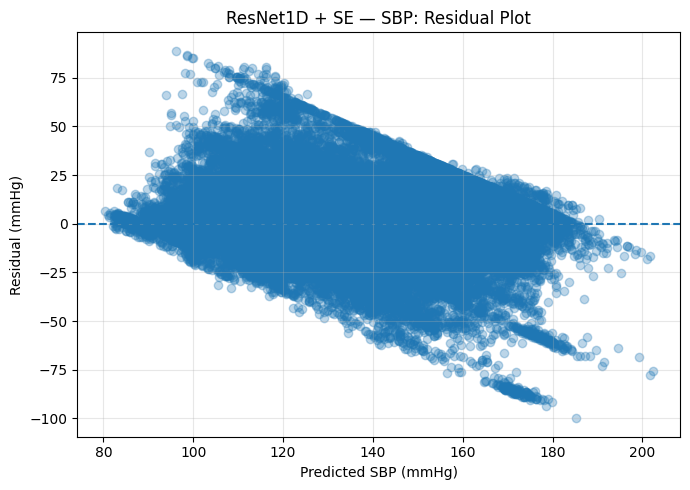

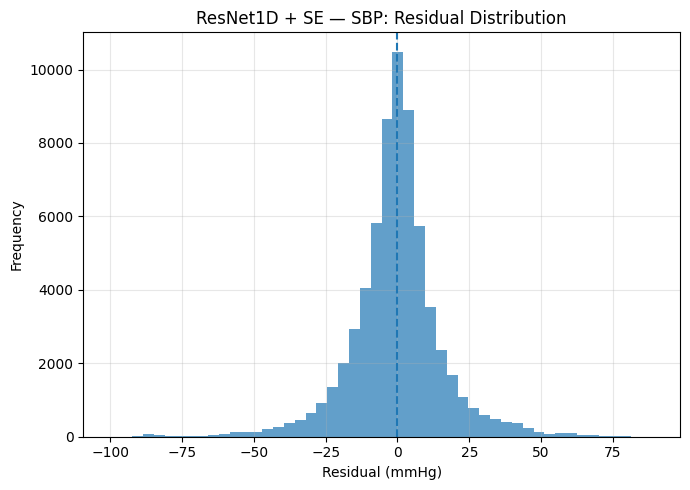

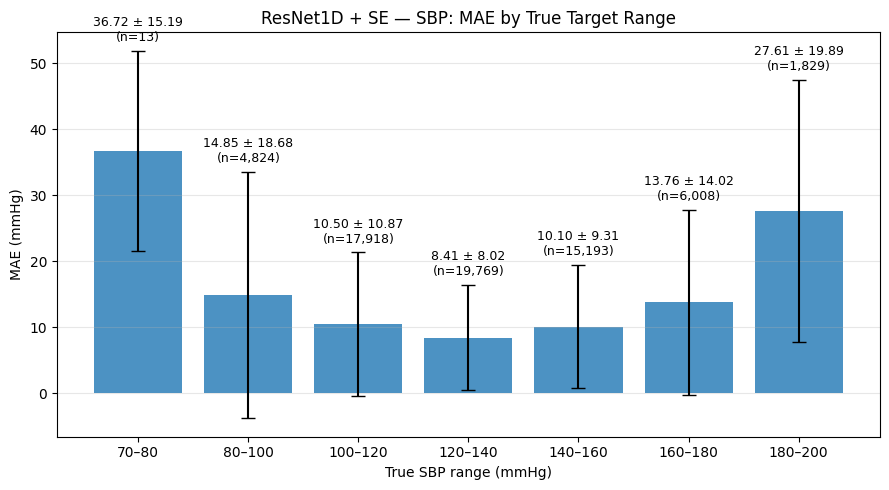

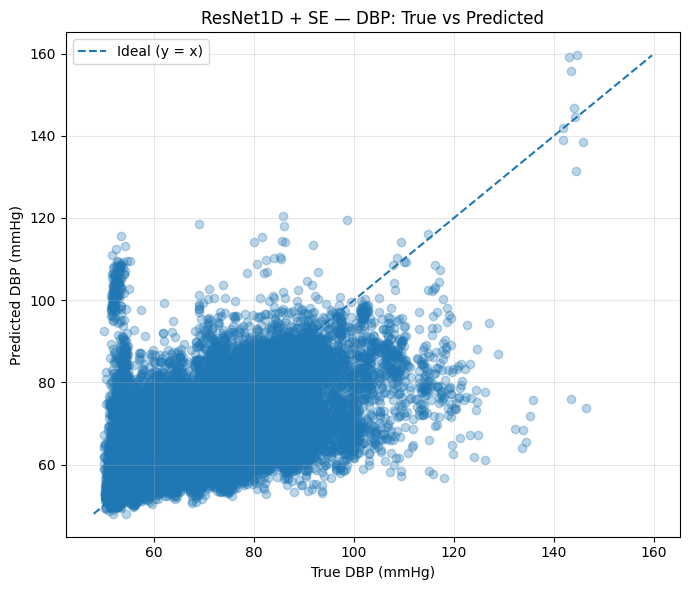

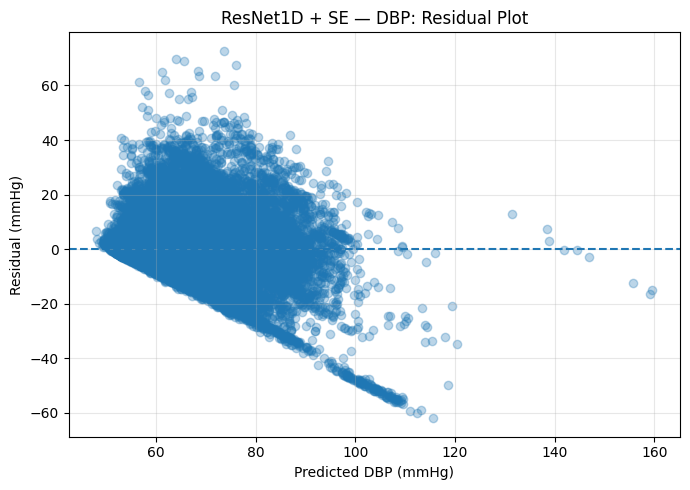

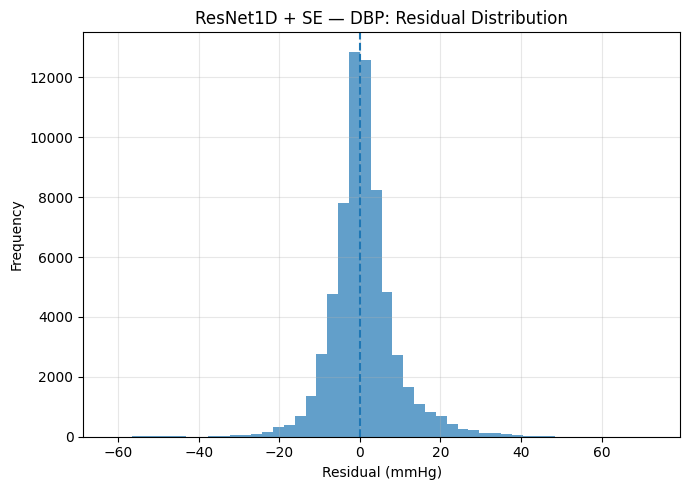

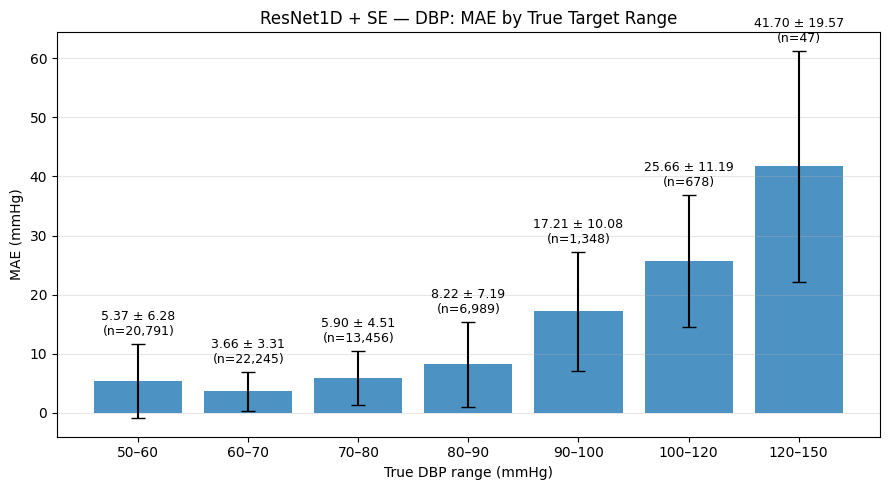

In [7]:
resnet_se_model, resnet_se_results = train_resnet1d_se(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10,
    reduction=16
)

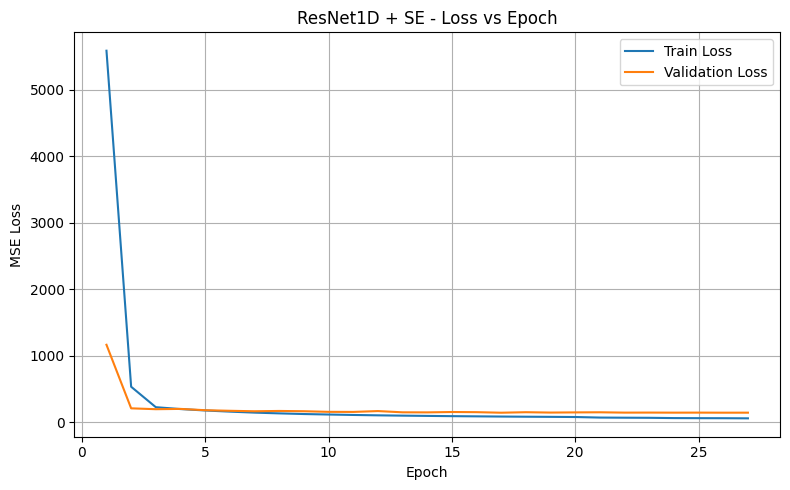

In [8]:
plot_loss_vs_epoch(
    resnet_se_results["history"],
    model_name="ResNet1D + SE"
)

Number of VitalDB cases: 1962


ResNet1D VitalDB prediction: 100%|██████████| 1962/1962 [09:43<00:00,  3.36case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 28.2334
MSE : 797.1237
R²  : -0.8687
MAE : 22.4664

DBP
RMSE: 14.8258
MSE : 219.8048
R²  : -0.3588
MAE : 11.6487


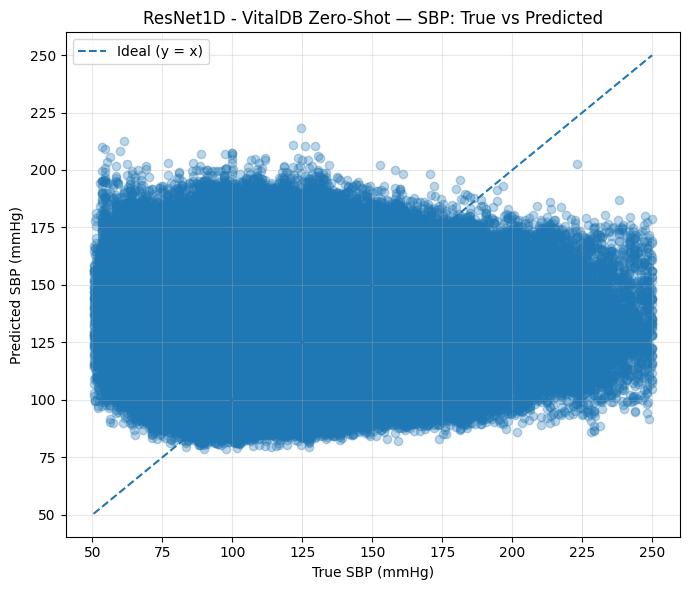

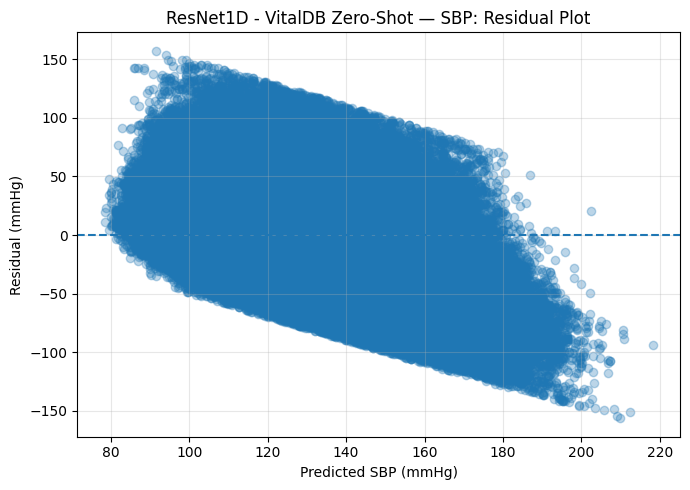

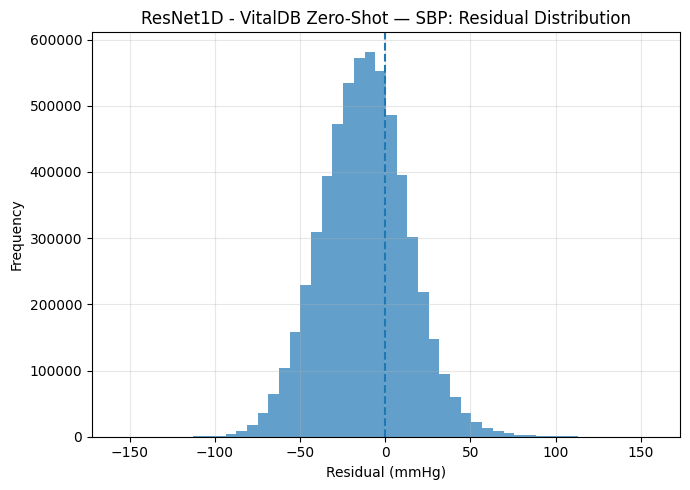

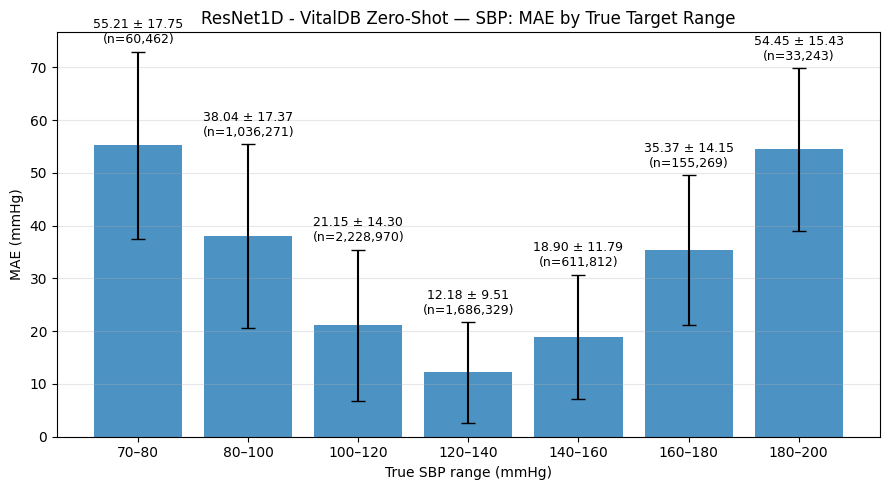

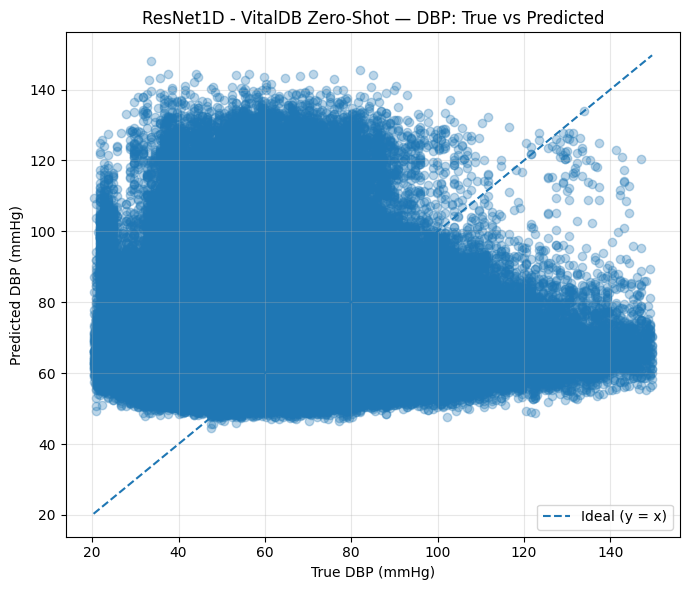

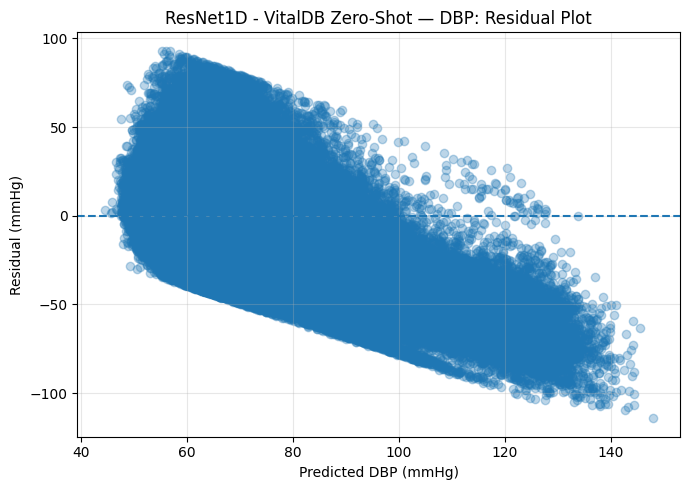

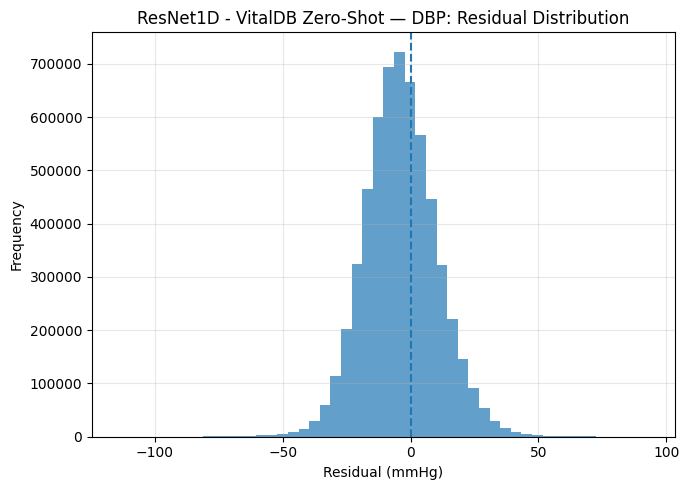

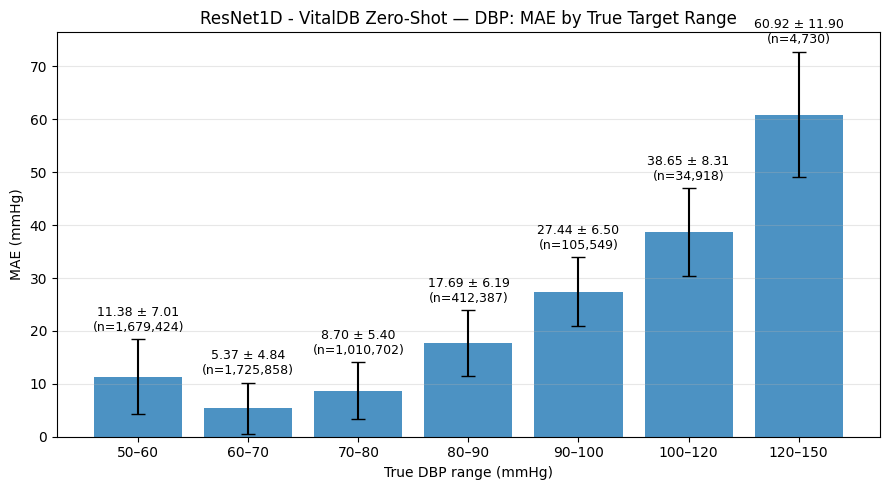

In [9]:
resnet_se_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_se_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## CBAM ##

Device: cuda
X_train: torch.Size([517037, 1, 1000])
X_val: torch.Size([65284, 1, 1000])
X_test: torch.Size([65554, 1, 1000])
Epoch 01/100 | Train Loss: 5607.0515 | Val Loss: 1168.7331 | Train SBP RMSE: 97.324 | Train DBP RMSE: 41.740 | Val SBP RMSE: 47.185 | Val DBP RMSE: 10.536 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 399.3773 | Val Loss: 202.8443 | Train SBP RMSE: 26.241 | Train DBP RMSE: 10.496 | Val SBP RMSE: 17.886 | Val DBP RMSE: 9.261 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 202.1553 | Val Loss: 176.9381 | Train SBP RMSE: 17.605 | Train DBP RMSE: 9.715 | Val SBP RMSE: 16.619 | Val DBP RMSE: 8.813 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 177.1300 | Val Loss: 185.6427 | Train SBP RMSE: 16.424 | Train DBP RMSE: 9.193 | Val SBP RMSE: 17.195 | Val DBP RMSE: 8.696 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 158.1936 | Val Loss: 157.9427 | Train SBP RMSE: 15.448 | Train DBP RMSE: 8.818 | Val SBP RMSE: 15.545 | Val DBP RMSE: 8.616 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 144.4231 | Va

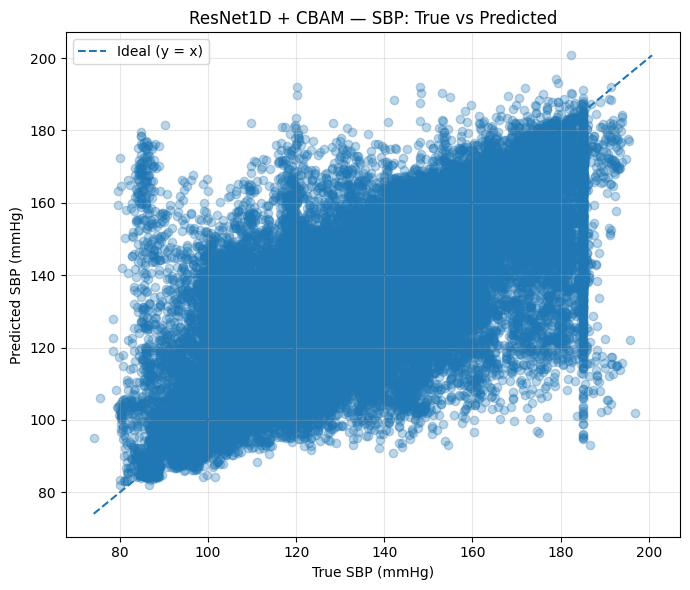

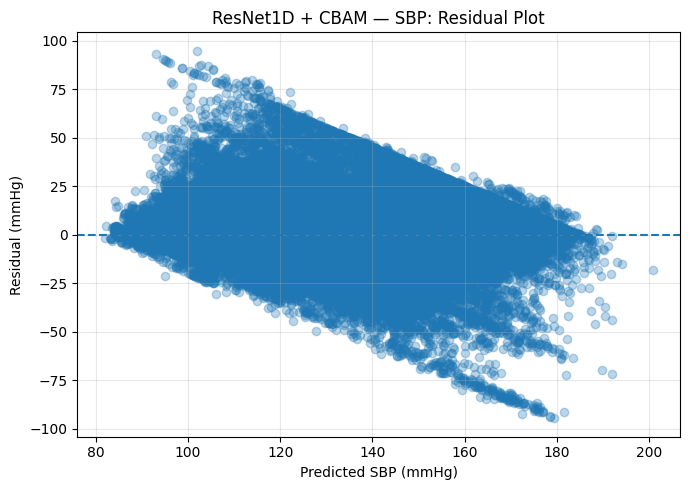

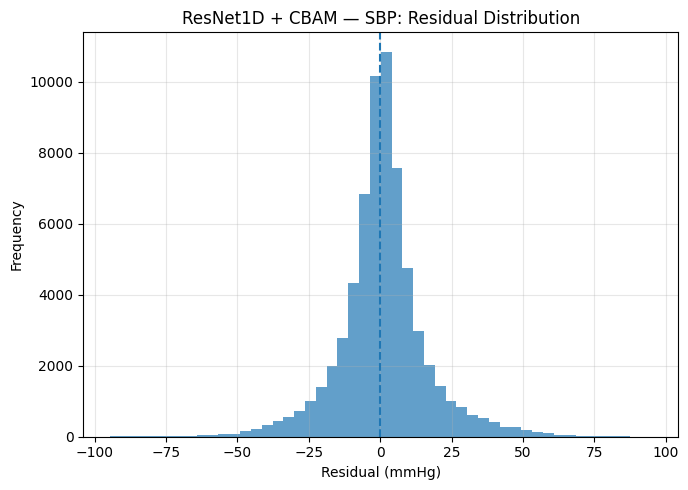

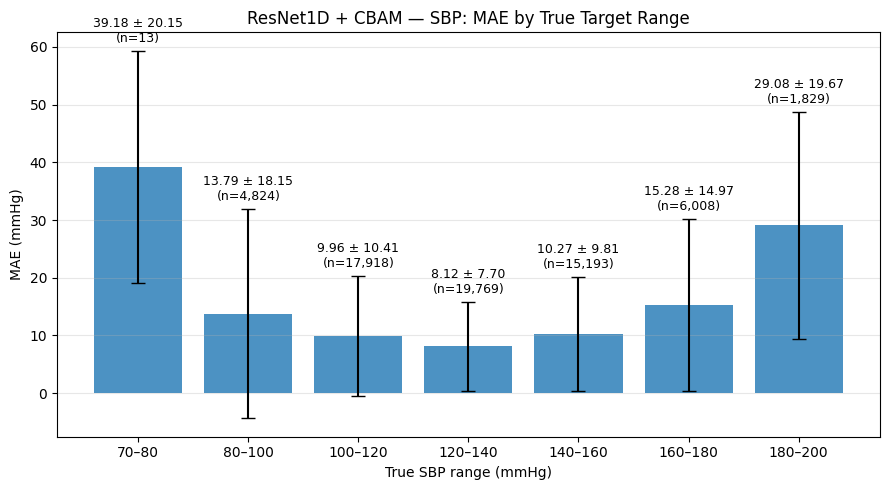

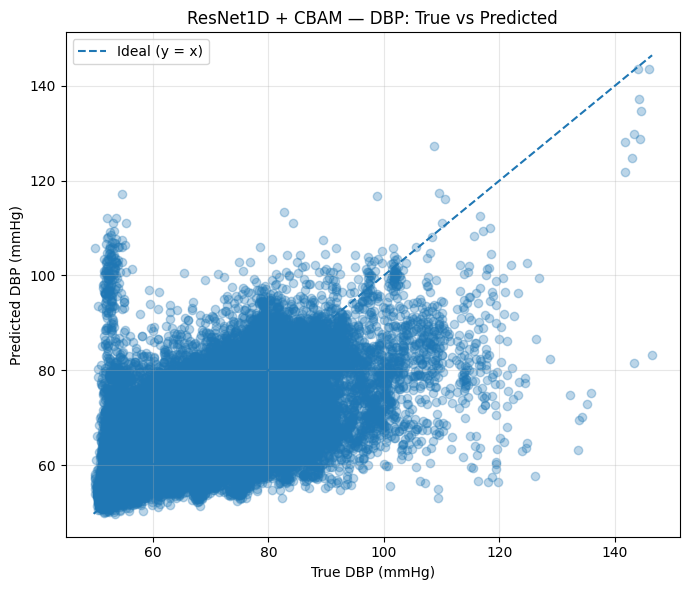

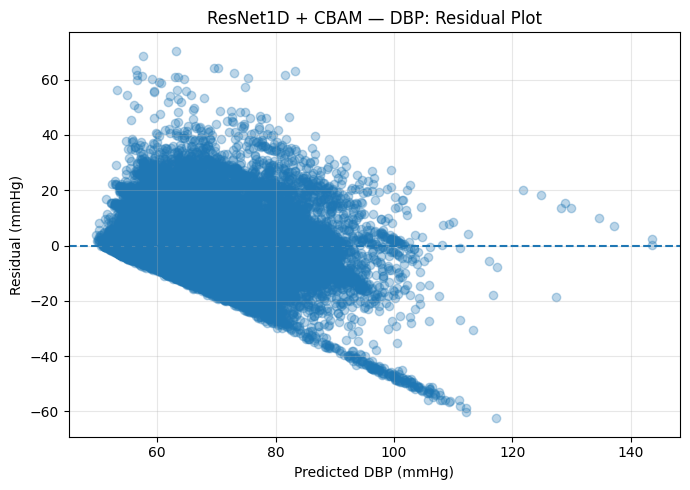

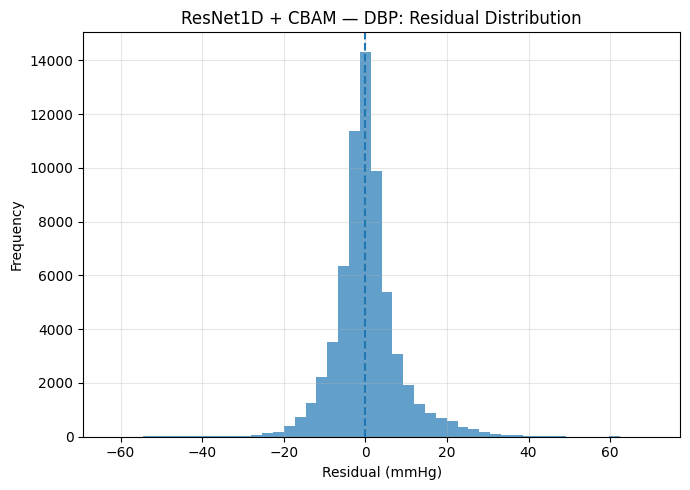

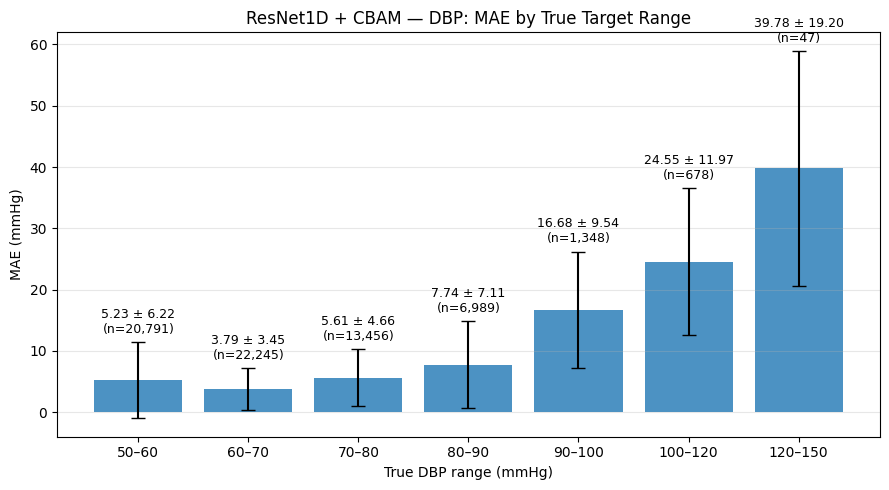

In [10]:
cbam_model, cbam_results = train_resnet1d_cbam(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

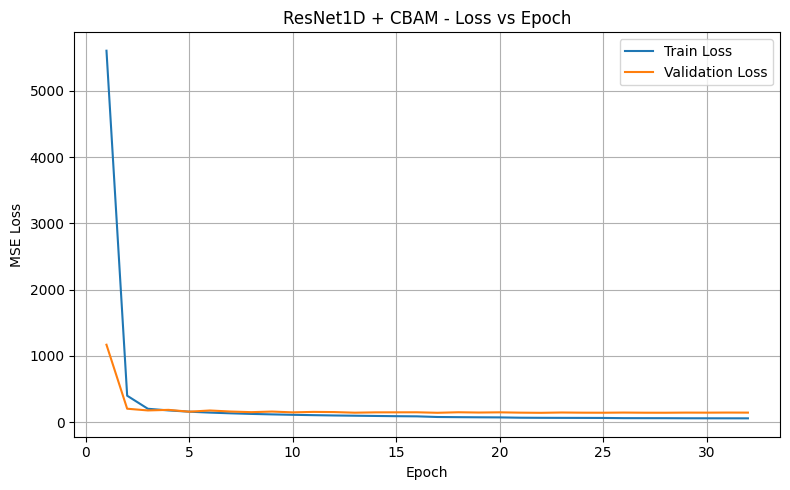

In [11]:
plot_loss_vs_epoch(
    cbam_results["history"],
    model_name="ResNet1D + CBAM"
)

Number of VitalDB cases: 1962


ResNet1D VitalDB prediction: 100%|██████████| 1962/1962 [04:56<00:00,  6.61case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.7214
MSE : 661.5904
R²  : -0.5510
MAE : 20.2365

DBP
RMSE: 14.4019
MSE : 207.4153
R²  : -0.2822
MAE : 11.2283


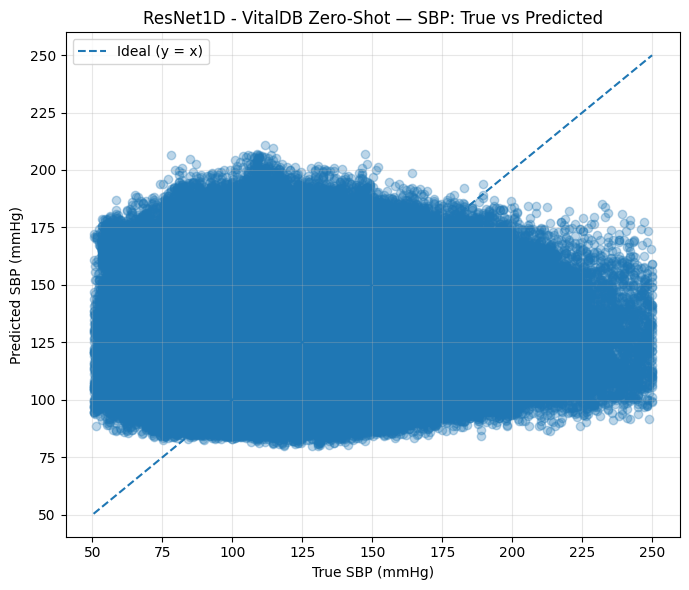

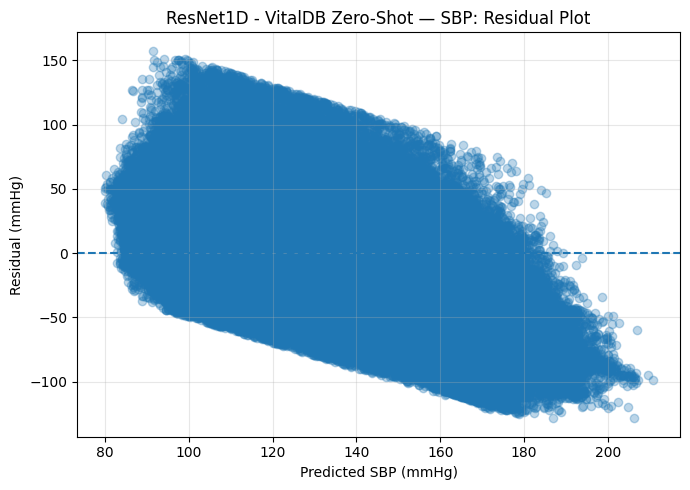

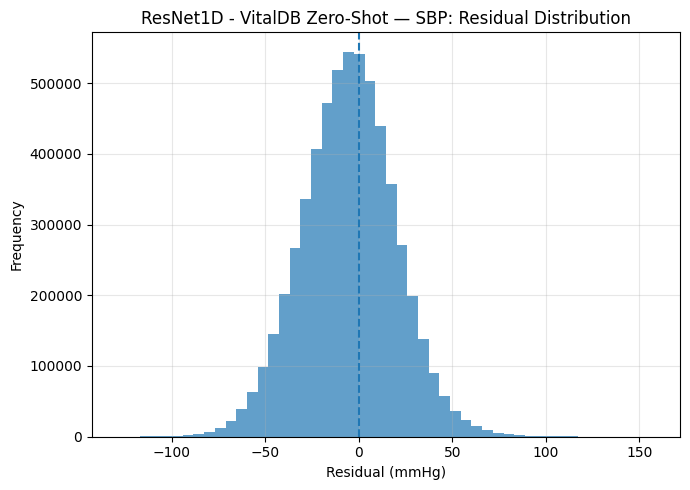

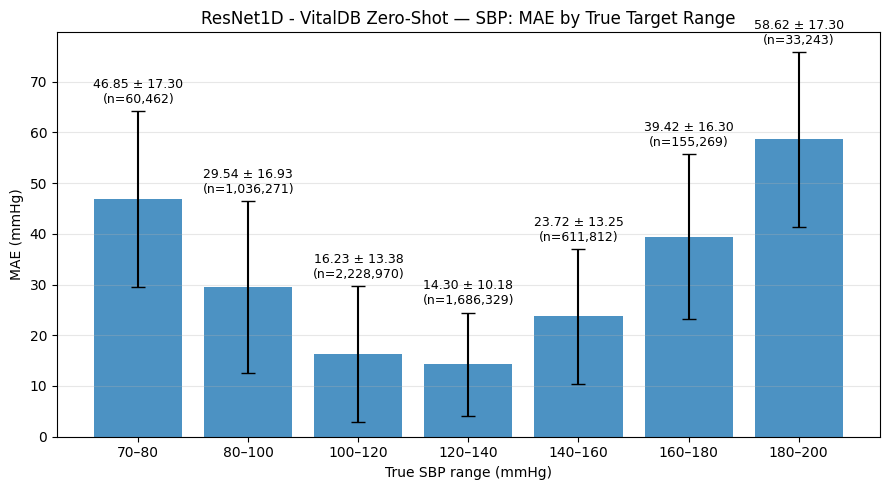

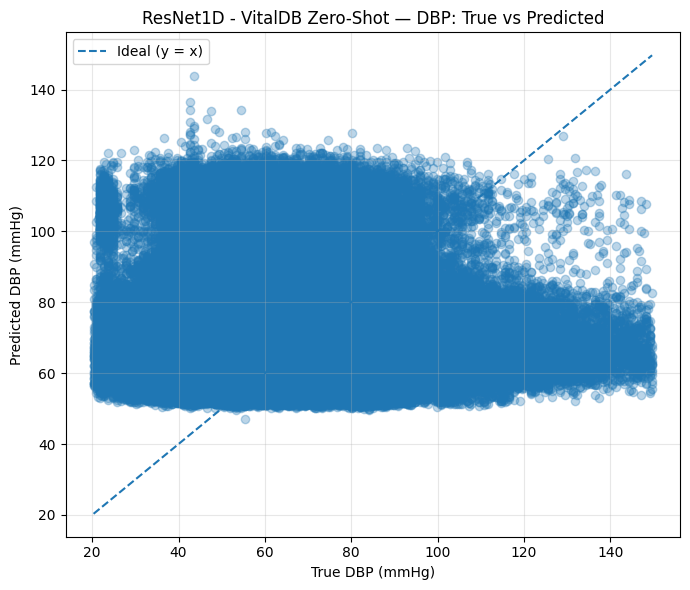

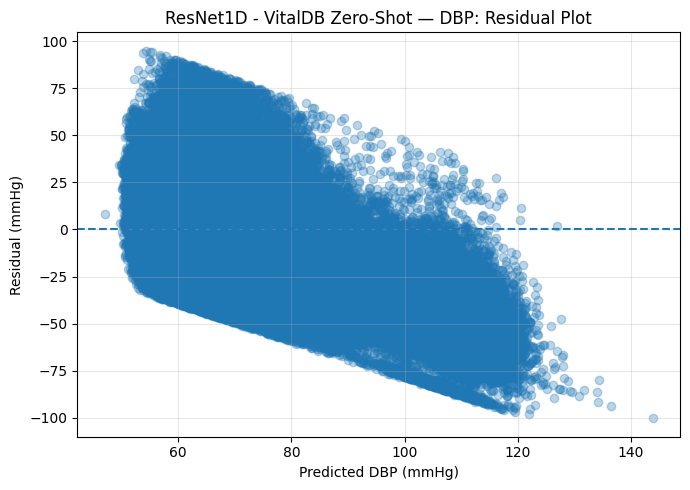

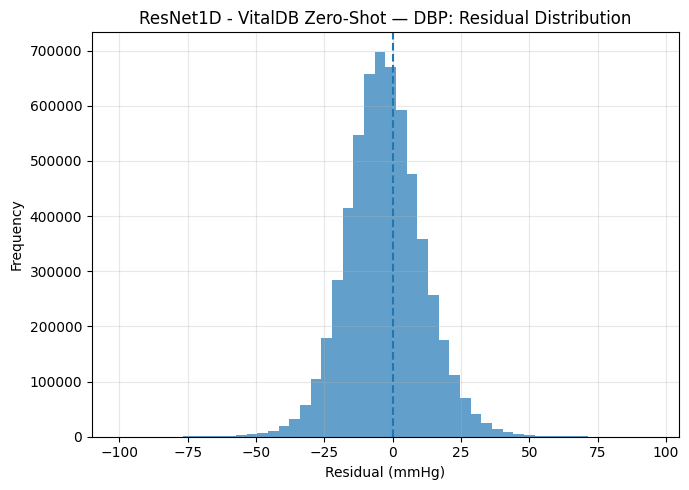

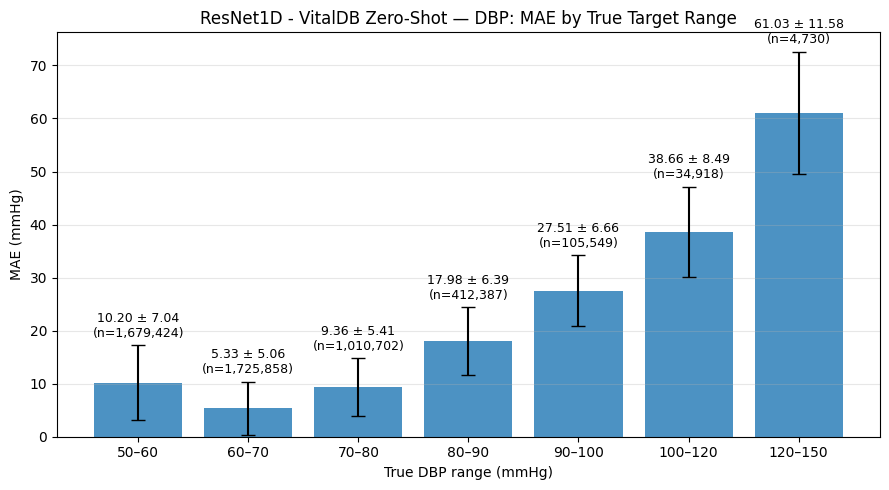

In [12]:
cbam_vitaldb_results = evaluate_resnet_vitaldb(
    model=cbam_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## DILATED ## 

Device: cuda
X_train: torch.Size([517037, 1, 1000])
X_val: torch.Size([65284, 1, 1000])
X_test: torch.Size([65554, 1, 1000])
Epoch 01/100 | Train Loss: 5376.6291 | Val Loss: 1123.6615 | Train SBP RMSE: 95.896 | Train DBP RMSE: 39.462 | Val SBP RMSE: 46.300 | Val DBP RMSE: 10.181 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 387.0680 | Val Loss: 187.4970 | Train SBP RMSE: 25.817 | Train DBP RMSE: 10.375 | Val SBP RMSE: 17.069 | Val DBP RMSE: 9.147 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 185.7763 | Val Loss: 178.4853 | Train SBP RMSE: 16.731 | Train DBP RMSE: 9.572 | Val SBP RMSE: 16.622 | Val DBP RMSE: 8.982 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 164.3354 | Val Loss: 170.2320 | Train SBP RMSE: 15.728 | Train DBP RMSE: 9.017 | Val SBP RMSE: 16.169 | Val DBP RMSE: 8.890 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 150.3117 | Val Loss: 165.9657 | Train SBP RMSE: 15.022 | Train DBP RMSE: 8.658 | Val SBP RMSE: 16.063 | Val DBP RMSE: 8.597 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 139.4642 | Va

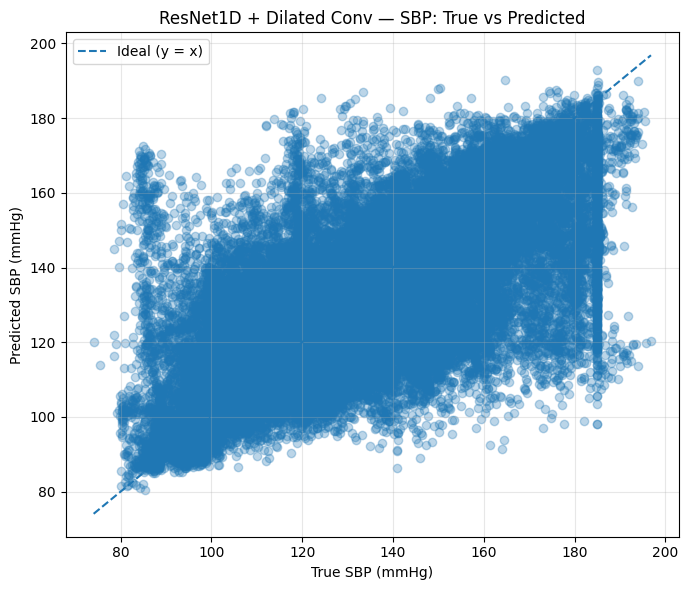

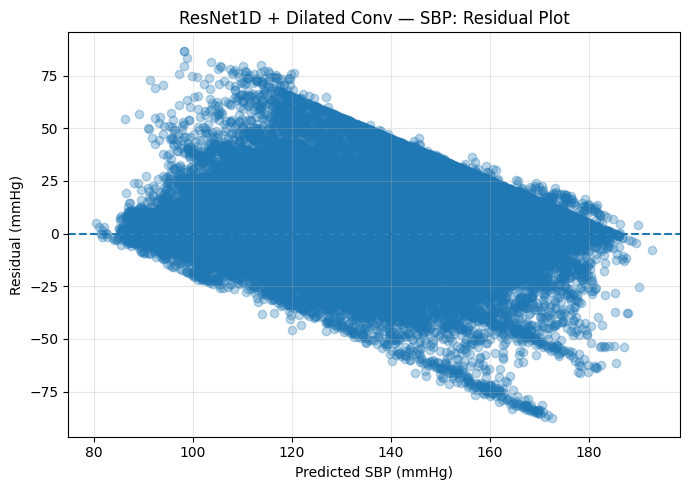

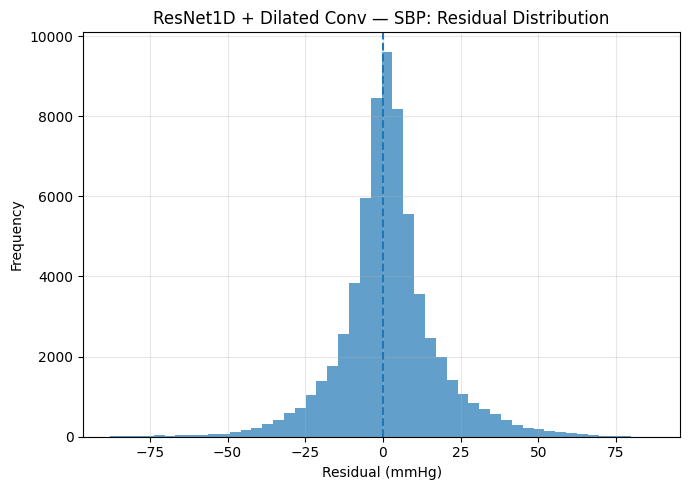

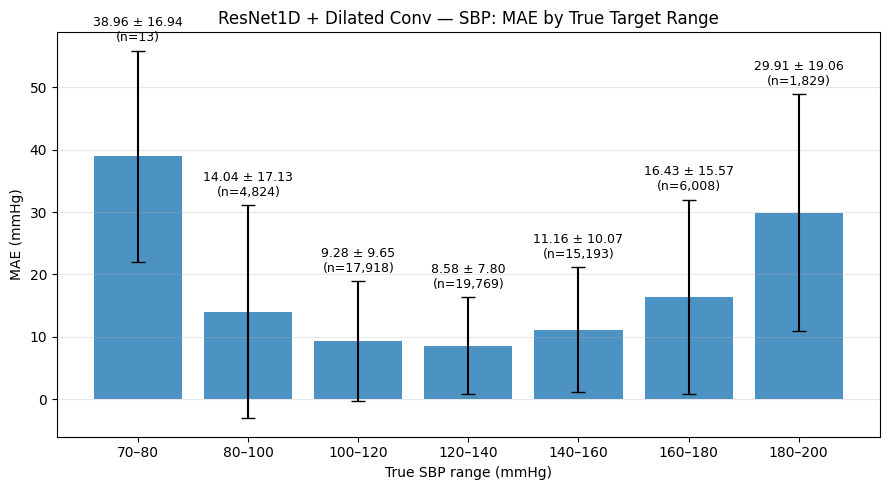

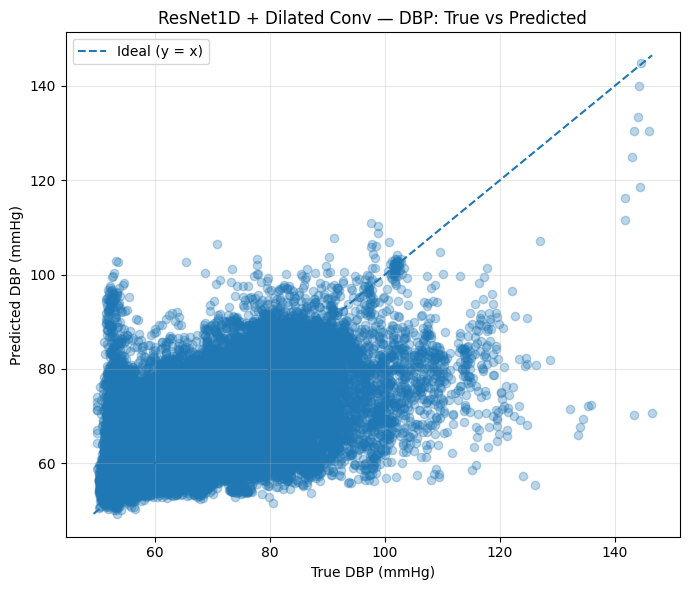

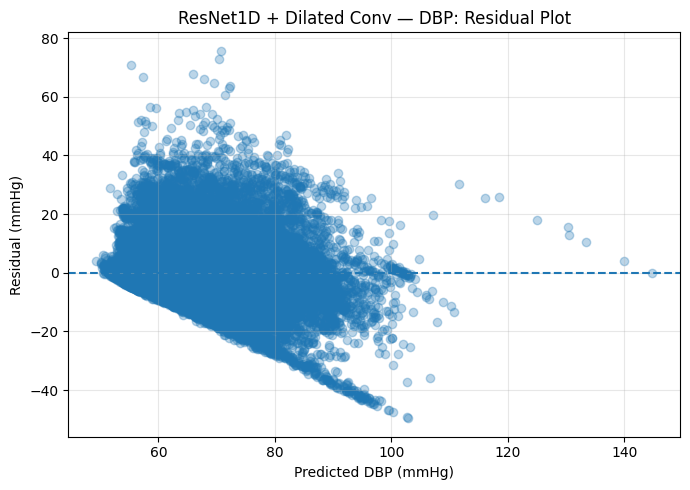

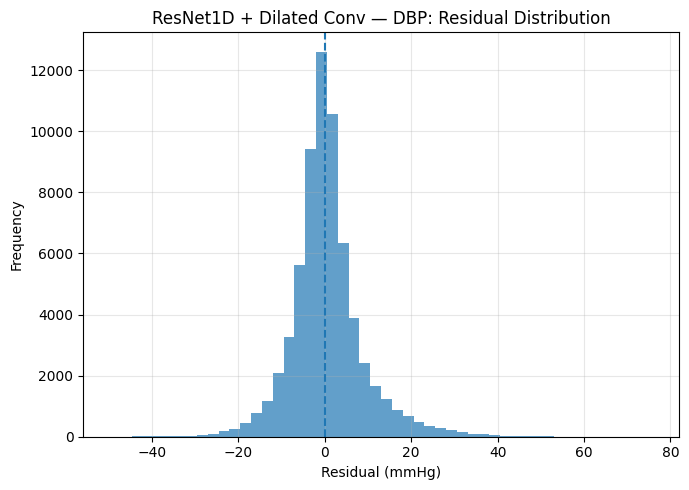

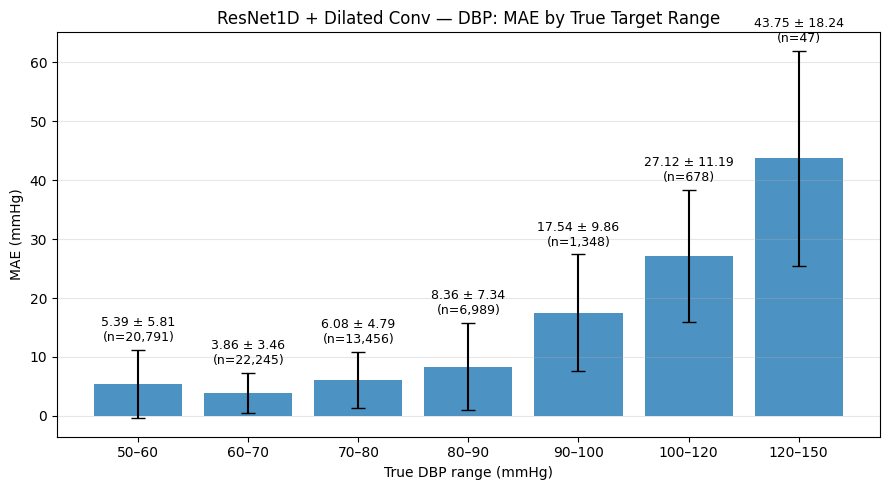

In [13]:
dilated_model, dilated_results = train_resnet1d_dilated(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

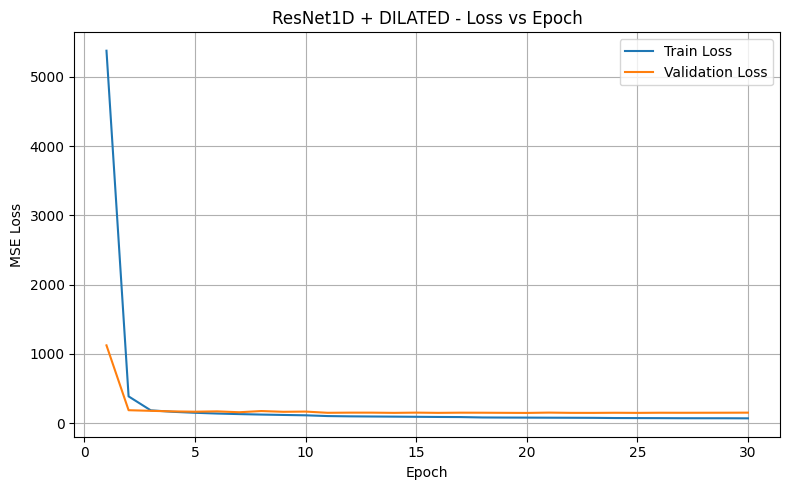

In [14]:
plot_loss_vs_epoch(
    dilated_results["history"],
    model_name="ResNet1D + DILATED"
)

Number of VitalDB cases: 1962


ResNet1D VitalDB prediction: 100%|██████████| 1962/1962 [12:21<00:00,  2.65case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 27.1604
MSE : 737.6884
R²  : -0.7294
MAE : 21.4522

DBP
RMSE: 15.1825
MSE : 230.5087
R²  : -0.4250
MAE : 11.9552


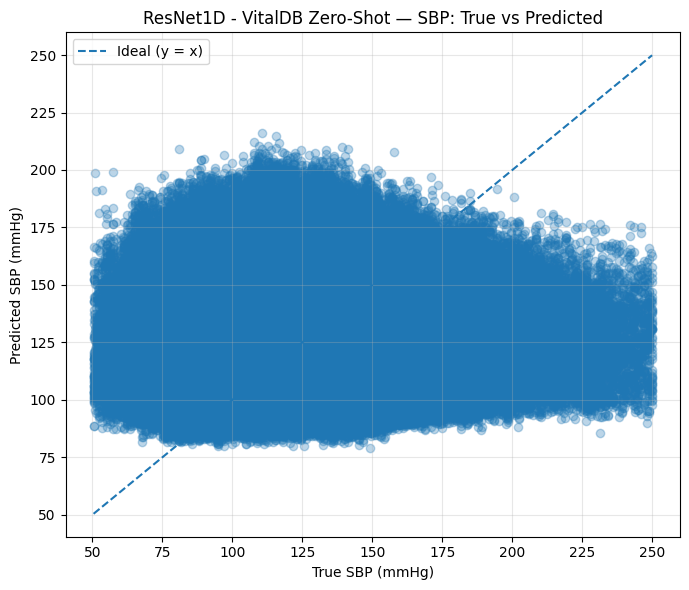

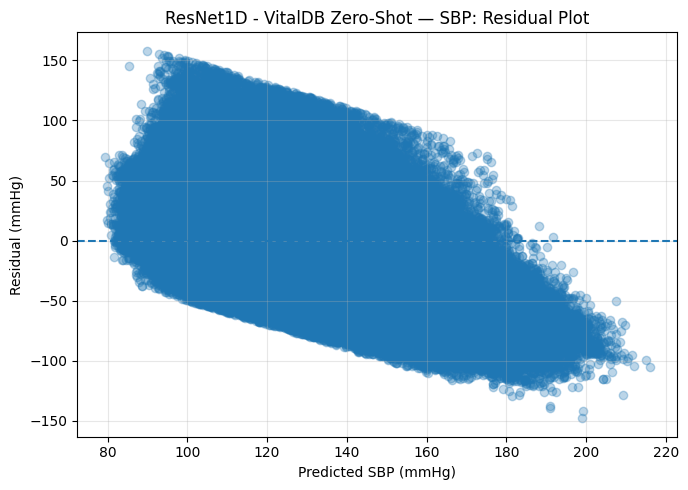

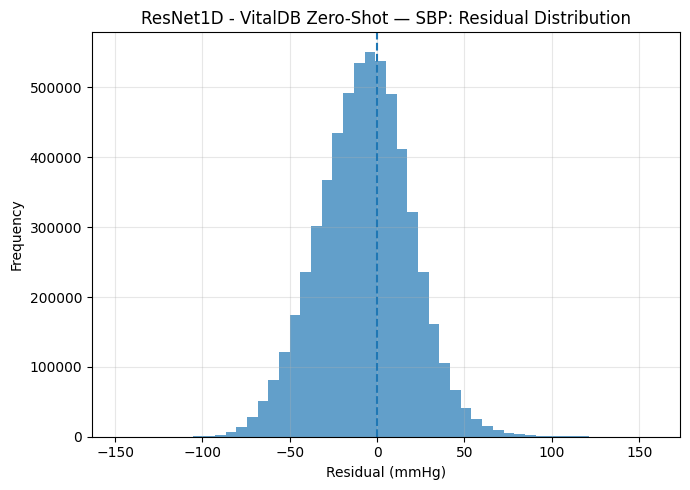

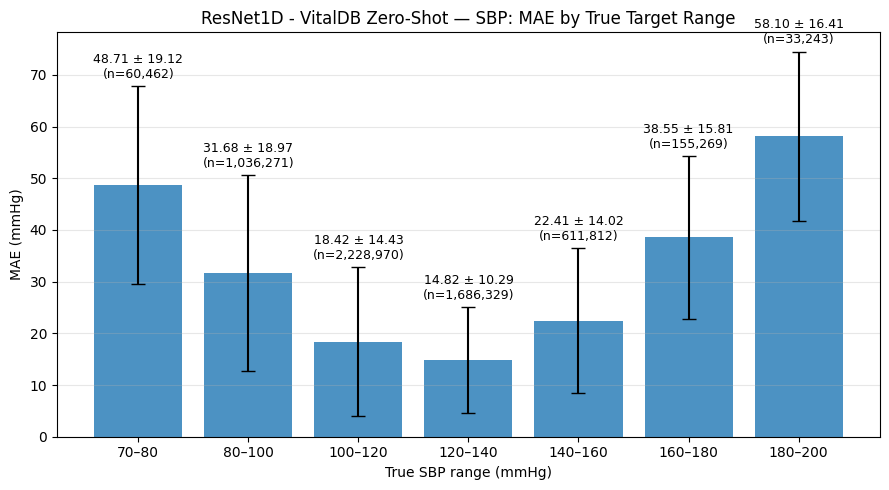

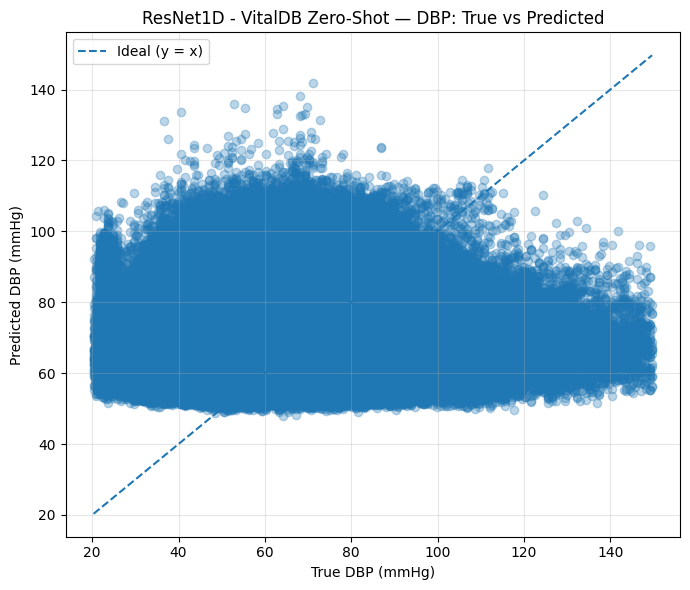

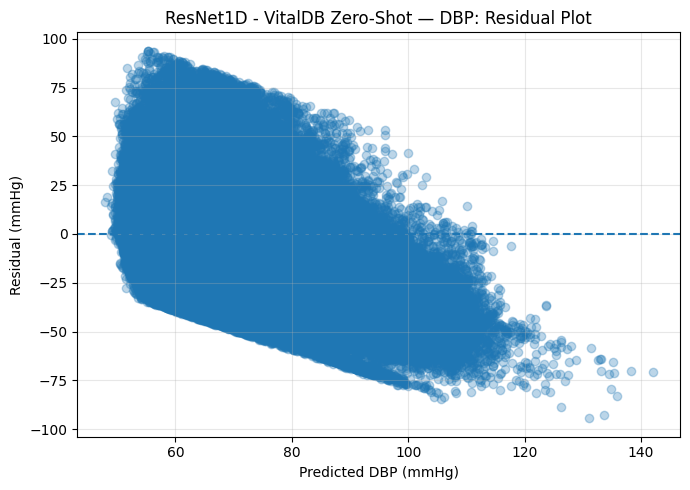

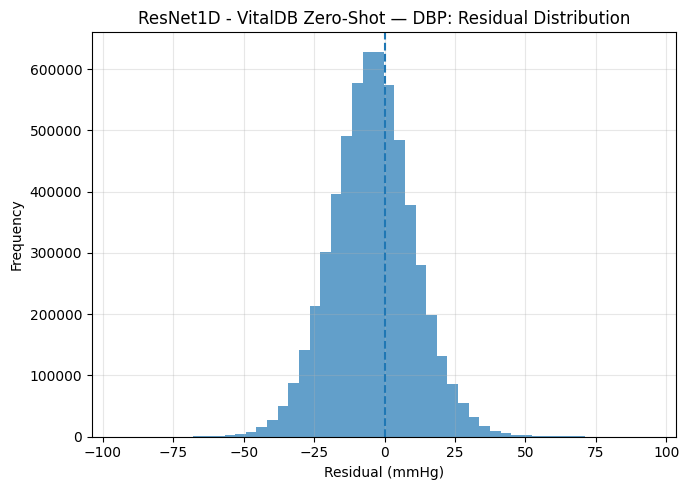

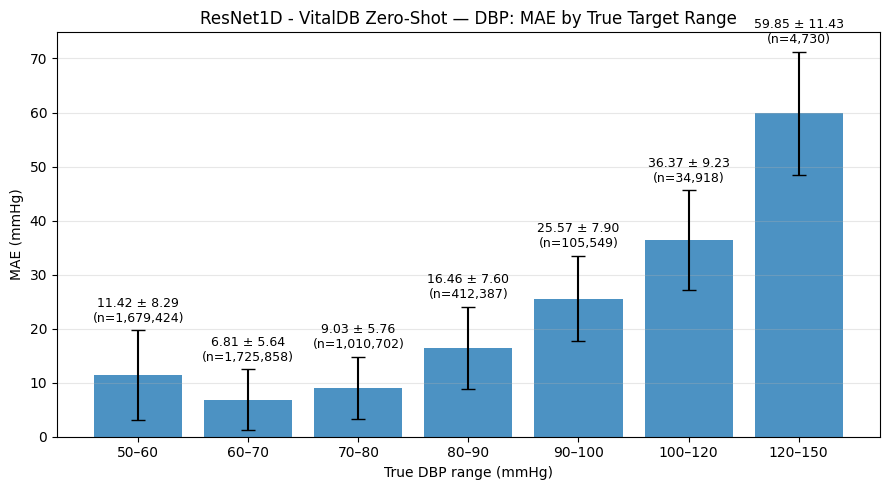

In [15]:
dilated_results = evaluate_resnet_vitaldb(
    model=dilated_model,
    base_dir=BASE_DIR,
    batch_size=256
)